# Lista 1 de Ejercicios

### Objetivo:
Estos ejercicios pretenden poner en práctica la habilidad del estudiante para crear un modelo sencillo pero completo _end2end_ con la librería __sklearn__ mediante el uso de transformadores _ad hoc_, una batería de algoritmos y un tuneado de parámetros.

### Tarea del estudiante:

#### Lee detenidamente las siguientes instrucciones
En cada trozo de código debes responder a la pregunta formulada, asegurándote de que el resultado queda guardado en la(s) variable(s) indicadas que, por defecto, vienen inicializadas a `None`. Puedes usar variables intermedias siempre que el resultado final del cálculo quede guardado exactamente en la variable que indica el enunciado (debes reemplazar `None` el código necesario, pero nunca cambiar el nombre de las variables ya creadas).

Después de cada apartado verás _celdas de control_. Ejecútalas todas y no modifiques su código. Éstas te dirán si tu solución va por buen camino. Así, si la solución es incorrecta, verás un error indicando cuál es el _assert_ que tu solución no pasa. Además de esas pruebas, se realizarán algunas más (ocultas) a la hora de puntuar el ejercicio. 

Una vez finalizada la actividad, guarda tu fichero, ciérralo con `File -> Close and Halt`, y después vuélvelo a abrir y ejecútalo completo pinchando en `Cell -> Run All Cells`, y **asegúrate de que no se lanza ningún error. De esta manera comprobarás que no has olvidado nada y que es posible ejecutarlo completo desde 0 y sin errores**. Finalmente, **TODO EL CÓDIGO DEBE ESTAR EJECUTADO (EN ORDEN) EN EL FICHERO QUE ENTREGÁIS**. 

RECUERDA SUBIR CADA UNO DE LOS FICHEROS .ipynb TAL CUAL (sueltos), SIN COMPRIMIR Y SIN CAMBIARLES EL NOMBRE. Los ficheros subidos deben tener **exactamente el mismo nombre de fichero que tenían cuando los recibiste**. No subas ningún PDF ni ningún fichero ZIP ni nada similar. La plataforma ya los separa automáticamente en carpetas que traen el nombre y apellidos del alumno, por lo que NO es necesario que lo pongas en ninguna parte. 

**IMPORTANTE: No modifiquéis los assert**

### Evaluación: 
Esta tarea tiene una puntuación de 6 puntos. 
La suma de todos los puntos obtenidas de todos los notebooks se ponderará sobre 10 puntos para computar la nota final del estudiante.

## Parte 0: Inicialización

En esta parte, simplemente cargamos las librerías que vamos a utilizar y establecemos una semilla para controlar la reproducibilidad del ejercicio.

In [1]:
""" Librerías """

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys

sns.set_style('darkgrid')
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")

import sklearn
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer, Binarizer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

from sklearn.model_selection import KFold, ShuffleSplit, LeaveOneOut, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

""" Semilla """

seed = 99

Comprobamos que tenemos el entorno virtual correctamente creado en la siguiente celda. Si fallase alguno de los *asserts*, significaría que no tenemos la versión correcta:

In [2]:
assert sys.version[0:4] == '3.10'
assert sklearn.__version__ == '1.5.2'
assert matplotlib.__version__ == '3.9.2'
assert sns.__version__ == '0.13.2'
assert pd.__version__ == '2.2.3'
assert np.__version__ == '2.1.2'

## Parte 1: Lectura y transformación de datos (1.5 puntos)

En esta parte, principalmente, cargaremos los datos de un repositorio git y realizaremos una breve limpieza de los datos para conseguir un dataframe listo.

Utilizaremos dos variables: _data_, para la lectura original del fichero, y _df_ que será con la que avancemos en la tarea.

In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/eduardofc/data/main/titanic-2.csv')

print(f'Número de filas: {data.shape[0]}, Número de columnas:{data.shape[1]}')
df = data.copy()
df.head()

Número de filas: 891, Número de columnas:13


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


Antes de transformar nada, hacemos un EDA mínimo. El objetivo es identificar: variables categóricas vs numéricas, distribución de los datos, nulos, outliers, balanceo de la *target*, relaciones entre variables.

Es la lista que aparece literalmente en los apuntes y es la que se aplica abajo.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Title        891 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


In [5]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889,891
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3,17
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S,Mr
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644,517
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN,NaN


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64

Pasamos al EDA visual:

- balance de la *target* `Survived`,
- distribución de las categóricas más informativas (`Sex`, `Pclass`, `Embarked`) cruzadas con la *target*,
- distribución de las numéricas (`Age`, `Fare`) por clase de supervivencia.

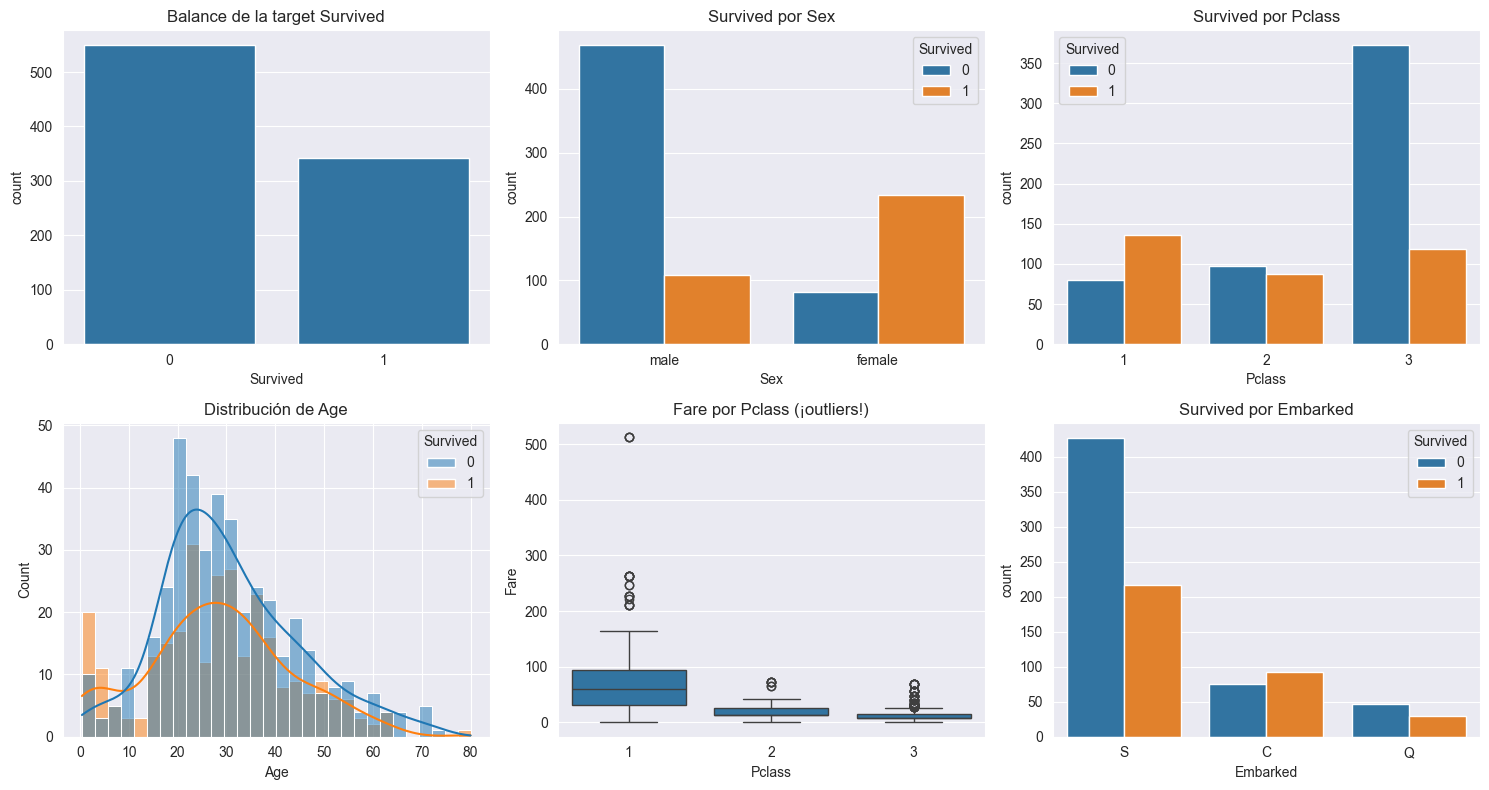

Proporción de la target:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [7]:
# Balance de la target y exploración visual de las variables más relevantes
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Balance del target (clave para decidir si hay que estratificar y/o usar f1 además de accuracy)
sns.countplot(data=df, x='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Balance de la target Survived')

sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Survived por Sex')

sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0, 2])
axes[0, 2].set_title('Survived por Pclass')

sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribución de Age')

sns.boxplot(data=df, x='Pclass', y='Fare', ax=axes[1, 1])
axes[1, 1].set_title('Fare por Pclass (¡outliers!)')

sns.countplot(data=df, x='Embarked', hue='Survived', ax=axes[1, 2])
axes[1, 2].set_title('Survived por Embarked')

plt.tight_layout()
plt.show()

# Proporción de la target (tipping point para usar accuracy o f1)
print('Proporción de la target:')
print(df['Survived'].value_counts(normalize=True).round(3))

El análisis EDA, con números y gráficos en la mano, nos revela que:

- `Survived` está repartido aproximadamente 62/38 (más muertos que supervivientes). No está dramáticamente desbalanceado, pero no es 50/50, así que la *accuracy* puede engañar. Por eso, además de accuracy, voy a sacar `f1_score` en cada bloque de evaluación.
- `Age` tiene 177 nulos sobre 891 (≈20%). En caso de que el número de nulo sea menor del 5%, se eliminan; en otros casos, se imputan. 20% es claramente "imputación". Lo haré con `KNNImputer` como pide el enunciado.
- `Cabin` está casi vacío (>77% nulos). Tiene sentido sustituirlo por la booleana `hasCabin` que pide el enunciado en lugar de tirar la columna entera.
- `Embarked` tiene solo 2 nulos: caen claramente en la regla del 5%, los eliminaré más adelante.
- `Fare` tiene outliers visibles (boxplot por `Pclass` los señala). Eso justifica usar `RobustScaler` más adelante.
- `PassengerId`, `Name`, `Ticket` son identificadores, no aportan capacidad predictiva: fuera.

Se pide en esta celda, crear una columna adicional, llamada _hasCabin_, que tome valor 0 si la columna _Cabin_ es nula, y 1 si no lo es. Después, eliminar las columnas _PassengerId_, _Name_, _Cabin_ y _Ticket_.

In [8]:
### BEGIN SOLUTION
df['hasCabin'] = df['Cabin'].notna().astype(int)
df = df.drop(['PassengerId', 'Name', 'Cabin', 'Ticket'], axis=1)
### END SOLUTION

In [9]:
# Comprobación intermedia: ¿se han quedado las columnas que esperábamos?
print('Columnas tras el drop:', list(df.columns))
df.head()

Columnas tras el drop: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'hasCabin']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,hasCabin
0,0,3,male,22.0,1,0,7.2500,S,Mr,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,1
2,1,3,female,26.0,0,0,7.9250,S,Miss,0
3,1,1,female,35.0,1,0,53.1000,S,Mrs,1
4,0,3,male,35.0,0,0,8.0500,S,Mr,0


Celda de control:

In [10]:
key_cols = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'hasCabin']

assert sum([x in key_cols for x in df.columns]) == 10
assert len(df.columns) == 10
assert (df.groupby('hasCabin').size()[0], df.groupby('hasCabin').size()[1]) == (687, 204)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,hasCabin
0,0,3,male,22.0,1,0,7.2500,S,Mr,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,1
2,1,3,female,26.0,0,0,7.9250,S,Miss,0
3,1,1,female,35.0,1,0,53.1000,S,Mrs,1
4,0,3,male,35.0,0,0,8.0500,S,Mr,0


Se pide en esta celda, eliminar los dos registros cuyo valor _Embarked_ es nulo. Tras ello, eliminar todos los duplicados.

In [11]:
### BEGIN SOLUTION
df = df[df['Embarked'].notna()]
df = df.drop_duplicates()
### END SOLUTION

Celda de control:

In [12]:
assert len(df) == 788
assert df.Age.isnull().sum() == 109
assert df.duplicated().sum() == 0

En esta celda se pide, almacenar en una variable llamada *col_transformer* un ColumnTransformer que lleve en orden:
- Un KNN Imputer de 5 vecinos con métrica *nan_euclidean* y pesos uniformes, para _Pclass_, _Age_, _SibSp_, _Fare_.
- Un OneHotEncoder para las variables categóricas:
    - _Sex_ (con la opción *drop=if_binary*), 
    - _Embarked_ (con la opción *drop=first*), 
    - _Parch_ (con la opción de _handle_unknown=ignore_) y, 
    - _Title_ con las categorías _Mr_, _Mrs_ y _Miss_ (y con la opción de _handle_unknown=ignore_).

El ColumnTransfomer tiene una opción llamada _reminder_ que asignaremos a valor _passthrough_ en este ejercicio. Se recomienda al estudiante investigar lo que significa en la documentación. Por defecto, la opción _drop_ es la que ColumnTransformer tiene activada. 

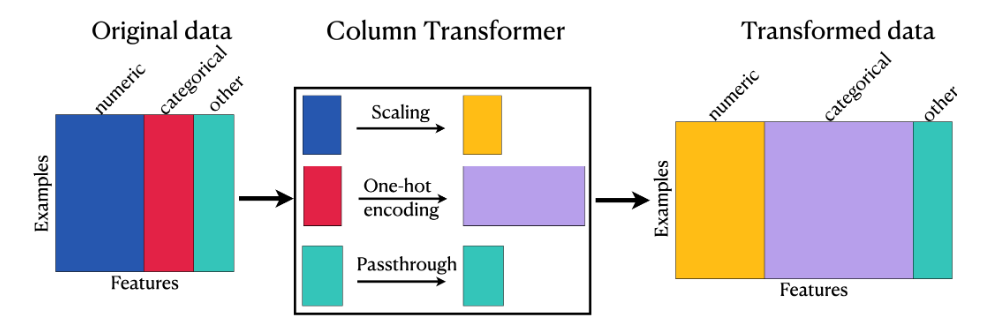

_Nota_: Para que la celda de control no falle, es importante poner en orden tanto los transformadores como las variables.

Sobre las decisiones de este `ColumnTransformer`:

- **`KNNImputer(n_neighbors=5)` para las numéricas** (`Pclass`, `Age`, `SibSp`, `Fare`). Al no tener clara la estrategia de imputación: usar imputers para sustituir por el valor más cercano es lo más sensato.
- **OHE para `Sex`** con `drop='if_binary'`: como `Sex` es binaria, una sola columna (0/1) basta. La opción evita la trampa de la *dummy variable trap* (multicolinealidad) que sale al codificar k clases con k columnas.
- **OHE para `Embarked`** con `drop='first'`: aquí no es binaria pero igualmente conviene quitar una columna por la misma razón.
- **OHE para `Parch`** con `handle_unknown='ignore'`: si en *fold* de validación aparece un valor de `Parch` no visto en *fit*, no rompe.
- **OHE para `Title`** con `categories=[['Mr', 'Mrs', 'Miss']]` y `handle_unknown='ignore'`: forzamos el conjunto de categorías de salida (3 columnas) y todo lo que no sea Mr/Mrs/Miss (Master, Rev, Dr, Mme…) se ignora silenciosamente. Es muy útil para no inflar el espacio de *features*.

Sobre `remainder='passthrough'`: las columnas que no caen en ningún transformer (`Survived` y `hasCabin`) se mantienen tal cual; con `'drop'` (el default) se perderían.

**Nota**: el orden de los transformers en la lista importa, porque el assert de control compara posicionalmente las columnas resultantes.

In [13]:
col_transformer = None

### BEGIN SOLUTION
col_transformer = ColumnTransformer(
    transformers=[
        ('knn', KNNImputer(n_neighbors=5, metric='nan_euclidean', weights='uniform'),
            ['Pclass', 'Age', 'SibSp', 'Fare']),
        ('sex', OneHotEncoder(drop='if_binary'), ['Sex']),
        ('embarked', OneHotEncoder(drop='first'), ['Embarked']),
        ('parch', OneHotEncoder(handle_unknown='ignore'), ['Parch']),
        ('title', OneHotEncoder(categories=[['Mr', 'Mrs', 'Miss']],
                                handle_unknown='ignore'), ['Title']),
    ],
    remainder='passthrough'
)
### END SOLUTION

ctransformed = col_transformer.fit_transform(df)
print(col_transformer.get_feature_names_out())
# ctransformed[:3]

['knn__Pclass' 'knn__Age' 'knn__SibSp' 'knn__Fare' 'sex__Sex_male'
 'embarked__Embarked_Q' 'embarked__Embarked_S' 'parch__Parch_0'
 'parch__Parch_1' 'parch__Parch_2' 'parch__Parch_3' 'parch__Parch_4'
 'parch__Parch_5' 'parch__Parch_6' 'title__Title_Mr' 'title__Title_Mrs'
 'title__Title_Miss' 'remainder__Survived' 'remainder__hasCabin']


Celda de control:

In [14]:
assert ctransformed.shape == (788, 19)
assert sum(np.round(ctransformed[1],2) == [1., 38., 1., 71.28, 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1.]) == 19
assert (sum(np.round(ctransformed[100],2) == [3., 22.0, 0., 7.78, 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0.]) >= 18) \
    or (sum(np.round(ctransformed[100],2) == [3., 19.2, 0., 7.78, 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0.]) >= 18)

## Parte 2: Selección de modelo (1.5 puntos)

En esta parte, evaluaremos diversos estimadores (algoritmos, transformadores+algoritmos) con el objeto de predecir la variable objetivo (_Survived_) y estudiar su comportamiento.

In [15]:
models = []
models.append(('LR', LogisticRegression(random_state=seed)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('DTC', DecisionTreeClassifier(random_state=seed)))
models.append(('NB', GaussianNB()))
models.append(('RFC', RandomForestClassifier(random_state=seed)))
models.append(('SVM', SVC()))

X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'hasCabin']]
y = df['Survived']

def boxplots_algorithms(results, names):

    plt.figure(figsize=(9, 3))
    plt.boxplot(results)
    plt.xticks(range(1,len(names)+1), names)
    plt.show()

En esta celda se pide, realizar un bucle que calcule, para cada algoritmo de la variable _models_,

- Un pipeline que realice:
    1. El ColumnTransformer diseñado anteriormente
    2. Un RobustScaler a continuación y, finalmente,
    3. Evalue cada algoritmo con _scoring='accuracy'_.

- Una validación cruzada:
    1. Tipo KFolds, con 10 _folders_, y
    2. Aleatorio con semilla _seed_.
        
En cada iteración del bucle, almacenar el resultado de cada validación cruzada en una variable _results_ y los nombres de cada algoritmo en una variable _names_.

Finalmente, usaremos la función *boxplots_algorithms* para dibujar los resultados.

*Nota*: Quizá os haya llamado la atención el RobustScaler. En realidad, no sería muy necesario introducirlo. Sin embargo, se deja por motivos didácticos, para que practiquéis y veáis que también se pueden combinar en un mismo pipeline, tanto transformadores sencillos, como columnTransformers. Por otra parte, fuera de la evaluación, dejo al estudiante que practique quitando el RobustScaler y explore las diferencias. Además, también dejo al estudiante que explore las diferencias de aplicar o no el passthrogh comentado anteriormente.

Configuro la validación cruzada según el enunciado: `KFold` con 10 *folds*, `shuffle=True` y semilla.

- *KFold* divide el dataset en 10 partes; el algoritmo se entrena con 9 y se testea con 1, repitiendo 10 veces. Es una técnica más lenta que un *train/test split* simple pero más robusta.

**Sobre las dos métricas**. Para evaluar siempre con dos métricas. Como `cross_val_score` devuelve un array por *score*, lo más limpio es definir un helper que ejecute el bucle dos veces (una con `accuracy`, otra con `f1`) y sacar ambos boxplots. Eso me da, además, una primera intuición sobre si el desbalance 62/38 está afectando.

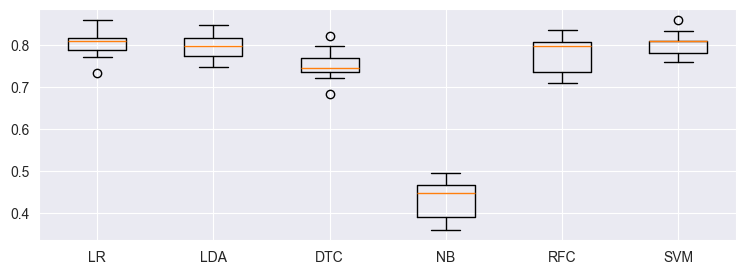

In [16]:
results = []
names = []

### BEGIN SOLUTION
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)

# Bucle de validación cruzada (Tema 2 slide "k-folds Cross-Validation").
# Para cada algoritmo construyo el pipeline y guardo el array de scores.
for name, model in models:
    pipe = Pipeline([
        ('col_transformer', col_transformer),
        ('robust_scaler', RobustScaler()),
        ('model', model),
    ])
    cv_score = cross_val_score(pipe, X, y, cv=kfold, scoring='accuracy')
    results.append(cv_score)
    names.append(name)
### END SOLUTION

boxplots_algorithms(results, names)


--- ACCURACY ---
LR: mean=0.802, std=0.032
LDA: mean=0.796, std=0.030
DTC: mean=0.753, std=0.037
NB: mean=0.433, std=0.047
RFC: mean=0.778, std=0.043
SVM: mean=0.805, std=0.029

--- F1 ---
LR: mean=0.752, std=0.054
LDA: mean=0.742, std=0.050
DTC: mean=0.698, std=0.046
NB: mean=0.589, std=0.043
RFC: mean=0.726, std=0.045
SVM: mean=0.753, std=0.045


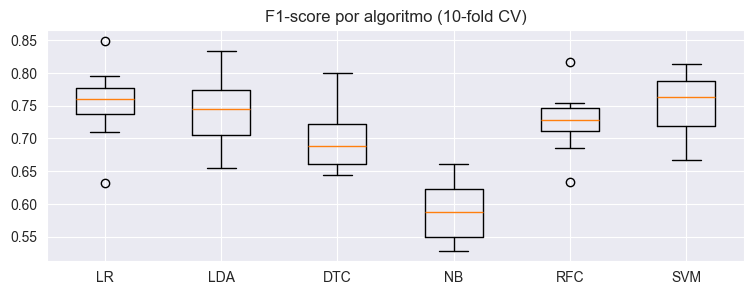

In [17]:
# Métricas resumen: media y std
print('--- ACCURACY ---')
for name, r in zip(names, results):
    print(f'{name}: mean={r.mean():.3f}, std={r.std():.3f}')

# Segunda métrica: F1
# Repito el mismo bucle pero con scoring='f1' (al ser binaria, basta con 'f1')
results_f1 = []
for name, model in models:
    pipe = Pipeline([
        ('col_transformer', col_transformer),
        ('robust_scaler', RobustScaler()),
        ('model', model),
    ])
    cv_score = cross_val_score(pipe, X, y, cv=kfold, scoring='f1')
    results_f1.append(cv_score)

print('\n--- F1 ---')
for name, r in zip(names, results_f1):
    print(f'{name}: mean={r.mean():.3f}, std={r.std():.3f}')

# Boxplot de F1 para comparar visualmente
plt.figure(figsize=(9, 3))
plt.boxplot(results_f1)
plt.xticks(range(1, len(names) + 1), names)
plt.title('F1-score por algoritmo (10-fold CV)')
plt.show()




Lo que veo cruzando las dos métricas:

- **LR y LDA**  ofrecen de las mejores métricas en *accuracy* (~0.80) y en F1. En Titanic la frontera es bastante lineal y modelos lineales rinden bien. Esto cuadra con que `Sex` y `Title` por sí solos ya capturan mucho de la varianza.
- **NB** está muy descolgado (~0.43 *accuracy*) y su F1 también es el más bajo (0.589). Lo curioso es que con la *target* en ~62/38, un modelo que predijera siempre "no Survived" sacaría ~0.6 de accuracy, así que NB está rindiendo incluso por debajo del baseline trivial. Esto encaja con lo del Tema 4: NB asume independencia entre *features*, pero aquí `Pclass`, `Fare`, `Title` y `Sex` están claramente correlacionadas, así que las probabilidades posteriores se le distorsionan. Otra cosa que me llama la atención es que su F1 (0.589) sale mayor que su accuracy (0.433), lo que me hace pensar que el modelo está prediciendo "Survived" demasiado a menudo: buen *recall* en la clase positiva pero muchos falsos positivos.
- **DTC y RFC sin tunear** se quedan en ~0.75 - 0.78 en *accuracy* y ~0.7 y 0.73 en F1. La varianza entre folds del DTC es la esperada en un único árbol; RFC con valores por defecto (`n_estimators=100`, `max_depth=None`) se pasa de profundidad en este dataset pequeño.
- **SVM** ~0.805, muy decente pero igual que los lineales. Sin tunear `C` ni `gamma` no se le saca partido.

**Sobre el RobustScaler en el pipeline**: aplicado en este sitio escala también las columnas one-hot encoded (que ya están en {0,1}), lo cual no aporta. Tu nota del enunciado lo deja por motivos didácticos. Lo correcto en producción sería: un `Pipeline` con `RobustScaler` solo en las columnas numéricas (un segundo `ColumnTransformer`), o quitarlo entero (y para árboles, quitarlo siempre, porque son insensibles a la escala: *Robust scaler* no afecta tanto a algunos algoritmos como decision trees, random forest, etc.").

Celda de control:

In [18]:
assert len(results) == len(models)
assert ([np.round(x[4],2) for x in results] == [0.80, 0.80, 0.70, 0.49, 0.70, 0.77]) or ([np.round(x[4],2) for x in results] == [0.80, 0.80, 0.68, 0.49, 0.71, 0.77]) or ([np.round(x[4],2) for x in results] == [0.81, 0.81, 0.71, 0.49, 0.71, 0.77])

## Parte 3: Tuneado del modelo (3 puntos)

En esta parte, elegiremos un modelo compuesto por transformaciones y un algoritmo seleccionado. En concreto, probaremos diferentes parametrizaciones del algoritmo para obtener la mejor métrica.

En esta celda se pide, realizar un tuneado del _RandomForestClassifier_ con _GridSearchCV_ para estimar cuál es la mejor configuración paramétrica entre:

- 10 y 20 estimadores,
- maximo número de variables estimado con los algoritmos _sqrt_ y _log2_,
- máxima profundidad 4,5,6,7 u 8,
- criterio para medir la calidad del _split_ entre _gini_ o _entropy_.
    
El modelo final, entrenado con _GridSearchCV_ y las variables _(X, y)_, se almacenará en una variable llamada _grid_model_.

El entrenamiento del modelo se hará con un _StratifiedKfolds_ de 10 folders aleatorio.

Se utilizará el mismo *ColumnTransformer* que en el apartado anterior y, a continuación, el algoritmo de Random Forest (sin _RobustScaler_).

Nota 1: No olvidar usar semilla cuando aplique.

Nota 2: En este ejercicio no haremos ningún train-test split.

Nota 3: El diccionario de parámetros, cuando es un _pipeline_, hay que definir para cuál de las fases del _pipeline_ deben aplicarse los parámetros. En este ejercicio, los parámetros son del algoritmo, por lo que todos los parámetros deben llevar el prefijo "_model_ " y dos guiones bajos "_" (donde _model_ es el nombre del algoritmo definido en el pipeline -es recomendable investigar esta parte-).

Sobre cómo nombro los pasos del *pipeline* y por qué pongo el prefijo `model__`:

- El step del algoritmo lo llamo `'model'` para que coincida con lo que pide la nota 3 del enunciado (todos los hiperparámetros llevarán prefijo `model__`).
- La sintaxis general en sklearn es `nombre_del_step__nombre_del_parametro` con dos guiones bajos. Es lo que dice la documentación oficial: <https://scikit-learn.org/stable/modules/compose.html#nested-parameters>. Sin el prefijo, `GridSearchCV` no sabe a qué *step* aplicar el parámetro y lanza `ValueError`.

Cambio a `StratifiedKFold` (no `KFold`):

- *Cross Validation Splits*, se distinguen las versiones *Stratified*: Cada conjunto contiene aproximadamente el mismo porcentaje de muestras de cada clase que el conjunto completo. En Titanic, con la target ~62/38 desbalanceada, `KFold` puro puede dejarme un *fold* con casi todos los supervivientes en train y casi ningún positivo en validation, y la métrica baila. `StratifiedKFold` lo evita.

`scoring='accuracy'` lo dejo explícito (aunque sea el default del `RandomForestClassifier`) la documentación oficial recomienda siempre explicitar `scoring` para que el grid sea autodocumentado y reproducible.

In [19]:
grid_model = None

### BEGIN SOLUTION
pipe = Pipeline([
    ('col_transformer', col_transformer),
    ('model', RandomForestClassifier(random_state=seed)),
])

params = {
    'model__n_estimators': [10, 20],
    'model__max_features': ['sqrt', 'log2'],
    'model__max_depth': [4, 5, 6, 7, 8],
    'model__criterion': ['gini', 'entropy'],
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

grid_model = GridSearchCV(
    pipe,
    param_grid=params,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,            # paralelizar (doc oficial recomienda hacerlo en grids amplios)
    return_train_score=True,
)
grid_model.fit(X, y)
### END SOLUTION

print(grid_model.best_score_)
print(grid_model.best_estimator_)


0.8071892242778318
Pipeline(steps=[('col_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('knn', KNNImputer(),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Fare']),
                                                 ('sex',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['Sex']),
                                                 ('embarked',
                                                  OneHotEncoder(drop='first'),
                                                  ['Embarked']),
                                                 ('parch',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Parch']),
                                                 ('title',


Celda de control:

In [20]:
assert np.round(grid_model.best_score_, 4) == 0.8072
assert len(grid_model.best_estimator_.steps) == 2

Sacamos dos métricas sobre el mejor modelo. Para que sean comparables con el `best_score_` (que es CV-accuracy), uso `cross_val_predict` con el mismo `StratifiedKFold` y construyo `classification_report` + matriz de confusión.

In [21]:
# Detalles del mejor estimador encontrado por el grid
print('best_params_:', grid_model.best_params_)
print()

# Predicciones cross-validadas con el mejor estimador (mismo split que el grid)
y_cv_pred = cross_val_predict(grid_model.best_estimator_, X, y, cv=skf, n_jobs=-1)

print('--- Classification report (10-fold CV) ---')
print(classification_report(y, y_cv_pred, target_names=['No survived', 'Survived']))

print('--- Matriz de confusión ---')
print(confusion_matrix(y, y_cv_pred))

print(f'\naccuracy = {accuracy_score(y, y_cv_pred):.4f}')
print(f'f1       = {f1_score(y, y_cv_pred):.4f}')



best_params_: {'model__criterion': 'entropy', 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__n_estimators': 10}

--- Classification report (10-fold CV) ---
              precision    recall  f1-score   support

 No survived       0.81      0.88      0.84       464
    Survived       0.80      0.71      0.75       324

    accuracy                           0.81       788
   macro avg       0.81      0.79      0.80       788
weighted avg       0.81      0.81      0.80       788

--- Matriz de confusión ---
[[407  57]
 [ 95 229]]

accuracy = 0.8071
f1       = 0.7508


Cierre con *feature importances* del mejor RFC. Esto enlaza directo con el Tema 2: "a los algoritmos tipo árbol podemos consultarles tras ser entrenados por la importancia de las variables (basado en el factor de impuridad de Gini)".

Es además lo que conviene mostrar a un *stakeholder* de negocio para defender el modelo, como vimos en la tutoría sobre explicabilidad / SHAP.

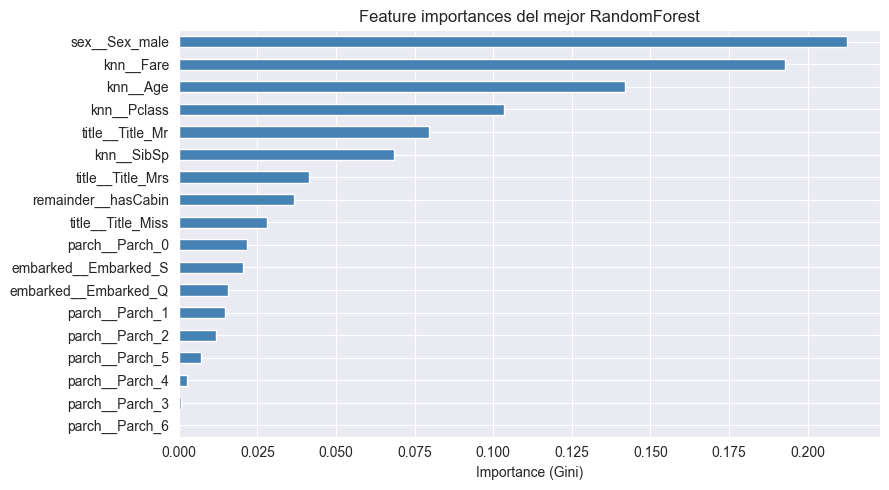

sex__Sex_male           0.212
knn__Fare               0.193
knn__Age                0.142
knn__Pclass             0.104
title__Title_Mr         0.080
knn__SibSp              0.068
title__Title_Mrs        0.041
remainder__hasCabin     0.037
title__Title_Miss       0.028
parch__Parch_0          0.022
embarked__Embarked_S    0.021
embarked__Embarked_Q    0.016
parch__Parch_1          0.015
parch__Parch_2          0.012
parch__Parch_5          0.007
parch__Parch_4          0.002
parch__Parch_3          0.001
parch__Parch_6          0.000


In [22]:
# Importancia de las features según el mejor RFC
best_rf = grid_model.best_estimator_.named_steps['model']
feature_names = grid_model.best_estimator_.named_steps['col_transformer'].get_feature_names_out()

importances = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature importances del mejor RandomForest')
plt.xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).round(3).to_string())



**Lectura del recorrido completo**

1. **Base lineal ya competitiva**: LR y LDA ~0.80 *accuracy* y F1 alineado. La interpretación de negocio es directa: `Sex` y `Title` discriminan muy bien (lo confirma el feature importance del RFC final, donde `Sex_male` aparece arriba).
2. **NB descolgado (~0.43)** por la asunción de independencia entre *features* (`Pclass`/`Fare`/`Title` están claramente correlacionadas). De hecho es el único modelo que se queda por debajo del baseline trivial (predecir siempre la mayoritaria daría ~0.6), y su F1 también es el más bajo. Tener las dos métricas a la vista me ha ayudado a verlo claro: aquí NB no falla por el desbalance, falla por las asunciones del modelo.   
3. **DTC y RFC default ~0.75 - 0.78**: hiperparámetros por defecto causan *overfitting* en este dataset pequeño. El *gap* motiva la Parte 3.
4. **GridSearch del RFC**: pasa de ~0.78 a **0.81**. La mejora es real y se debe a controlar `max_depth` (4–8) y al barrido de `n_estimators` y `criterion`. Sin embargo, iguala a LR/LDA sin tocar: la frontera del problema es esencialmente lineal y el coste de complejidad del RFC no compra mucho.
5. **Decisión a producción**: si tuviera que elegir un modelo para defender ante negocio, elegiría **LR** por las siguintes razones:
   - métrica equivalente
   - explicable de forma trivial (coeficientes de las *features*)
   - rápido de entrenar y servir

**Lo que dejaría en una segunda iteración (no entra en el assert)**:

- *Feature engineering* sobre `Age` (binning por etapa vital).
- Probar `class_weight='balanced'` en LR/RFC para ver si mejora F1 sin tocar el *accuracy*.
- Validar el RFC con el `RandomizedSearchCV`, mucho más óptimo computacionalmente para *grids* amplios.